# C07 · Code walkthrough: powertrain assembly (ports, topologies, compatibility, redundancy, machine data, installation)

**Track:** code walkthroughs. Every listing is printed from the repository with its real line numbers
(`show_source`). C01 covered the generic layer (`core/ports.py`, `core/topology.py`, `core/margins.py`). This notebook
covers the powertrain-specific layer on top of it: which ports each component has, how the series-hybrid network is
wired, how ratings are compared (compatibility margins), how failure states are read from the network (redundancy),
the machine database fit, and how the network is placed on the airframe for mass and CG.

Everything runs on the **sized Halo**: the cached v3.6 baseline design, rebuilt with
`build_halo_aircraft(ref.design, HaloRequirements(), baseline_assumptions())`.

| Module | Lines | What it holds |
|---|---|---|
| `powertrain/ports.py` | 56 | port declarations per component type; the rectifier's reversed ports; `port_specs_for` |
| `powertrain/topologies.py` | 204 | `ElectricalLayer`, `RedundancyLayer`, `build_series_hybrid`, the XV-15 mechanical topology, the old rubber reference |
| `powertrain/compatibility.py` | 264 | port envelopes, `battery_voltage_range_V`, `operating_margins`, `design_margins` |
| `powertrain/redundancy.py` | 94 | counts read from a topology, `degraded_state`, `battery_with_strings`, `battery_for_condition` |
| `powertrain/machine_database.py` | 105 | the supplier machine CSV loader and the torque-density power-law fit |
| `vehicle/powertrain_installation.py` | 70 | instances placed at x/z; installed mass and CG; the optional heat exchanger |

**Who imports what** (grep of `src/`, `examples/`, `tests/`):

| Module | Imported by (production) | Imports |
|---|---|---|
| `ports.py` | `topologies.py` (relative import) | `core.ports`, eleven component classes |
| `topologies.py` | `examples/halo_sizing.py`, `coupled_sizing.py`, `requirements_sizing.py`, `series_hybrid_point.py`, `xv15_reference.py` | `core.topology`, six components, `ports` |
| `compatibility.py` | `performance/flight_point.py` (`operating_margins` only), `examples/series_hybrid_point.py` | `core.margins`, `core.ports.Direction`, eleven components |
| `redundancy.py` | `performance/flight_point.py`, `mission/mission.py` | `Battery`, `EquivalentCircuitBattery` |
| `machine_database.py` | **no production importer**; only `tests/powertrain/test_machine_database.py` | `csv`, `numpy` |
| `powertrain_installation.py` | `examples/halo_sizing.py`, `aircraft_mass_closure.py`, `xv15_reference.py` | `aerosandbox` |

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "tutorials"))
from tutorial_helpers import *          # paths, plot style, check(), lb(), baseline(), capture_opti()

from dataclasses import replace
from examples.halo_sizing import (HaloRequirements, build_halo_aircraft, build_halo_aerodynamics,
                                  failure_hover_cases)
ref = baseline()
assumptions = baseline_assumptions()
aircraft = build_halo_aircraft(ref.design, HaloRequirements(), assumptions)
topology = aircraft.powertrain.topology
components = {name: instance.component for name, instance in topology.instances.items()}
print("instances:", {n: (type(i.component).__name__, i.count) for n, i in topology.instances.items()})
print("buses:", {n: b.count for n, b in topology.buses.items()})

instances: {'turboshaft': ('SimpleTurboshaft', 2), 'generator': ('Generator', 2), 'battery': ('EquivalentCircuitBattery', 1), 'motor': ('Motor', 4), 'gearbox': ('Gearbox', 2), 'propulsor': ('MomentumProfileRotor', 2), 'generator_gearbox': ('Gearbox', 2), 'protection_string': ('ProtectionUnit', 2), 'protection_bus_tie': ('ProtectionUnit', 1), 'cable_bus_tie': ('Cable', 1)}
buses: {'bus': 2}


---
## 1. `powertrain/ports.py`

In [2]:
show_source("src/aircraft_closure/powertrain/ports.py")

# src/aircraft_closure/powertrain/ports.py  lines 1-56
   1  """Port declarations for Tier 1 components, kept outside the component classes.
   2  
   3  Signs follow the Tier 1 conventions: motor current and generator current are
   4  positive in their working quadrants, battery current is positive on discharge,
   5  and gearbox/propulsor torque is positive in forward power transfer.
   6  """
   7  from aircraft_closure.core.ports import Direction, Domain, PortSpec
   8  from .components.battery import Battery
   9  from .components.battery_ecm import EquivalentCircuitBattery
  10  from .components.cable import Cable
  11  from .components.converters import DcDcConverter, Inverter
  12  from .components.gearbox import Gearbox
  13  from .components.generator import Generator
  14  from .components.motor import Motor
  15  from .components.protection import ProtectionUnit
  16  from .components.propulsor import ActuatorDiskPropulsor
  17  from .components.rotor import MomentumProfil

**Line by line**

- **L1-6 docstring:** the sign conventions every flight point relies on. Motor and generator current are positive in
  their working quadrant (motoring for a motor, generating for a generator). Battery current is positive on
  discharge. Gearbox and propulsor torque are positive in forward power transfer. These are the conventions that make
  `Direction` (C01) a sign convention and not a restriction.
- **L7-18 imports:** the generic `PortSpec` from `core`, and every component class that can appear in a topology.
  The components themselves import nothing from here. That is the point of the module: port declarations are kept
  **outside** the component classes (decision `002`, "a powertrain port declaration for each component"), so the
  physics classes stay plain dataclasses with `evaluate`, `get_limits` and `get_mass`, and know nothing about networks.
- **L20-43 `_port_specs_by_type`:** a dict from class to a tuple of `PortSpec`. Read it as the nominal power flow:
  - `Motor`: electrical IN, shaft OUT. `Generator`: shaft IN, electrical OUT.
  - `Battery` and `EquivalentCircuitBattery` (L25-26): one electrical OUT. Charging is negative current on that port.
    The ECM pack is a separate entry because it is not a subclass of `Battery` (checked below).
  - `SimpleTurboshaft` (L27-28): fuel IN, shaft OUT. The fuel port is never connected: it is a boundary port.
  - `Gearbox` (L29-30): `shaft_in` IN, `shaft_out` OUT. The same class serves as rotor reduction gearbox and as the
    generator step-up gearbox.
  - `ActuatorDiskPropulsor`, `MomentumProfileRotor` (L31-32): one shaft IN. They are sinks.
  - **L33-42 Tier 15 two-ports** (decision `023`): `Inverter` dc IN, ac OUT (motor drive direction); `Cable`,
    `ProtectionUnit`, `DcDcConverter` input IN, output OUT.
- **L46-48 `rectifier_port_specs`:** the generator's inverter is the same `Inverter` class run backwards (active
  rectifier). Its ports are reversed: ac IN, dc OUT. A type lookup cannot know the role, so the builder passes these
  specs explicitly (`topologies.py` L129).
- **L51-56 `port_specs_for`:** walks `type(component).__mro__`, so a subclass inherits its parent's ports. It
  raises `TypeError` for an unknown type (fail at build time, not at solve time).

**Run it**

In [3]:
from aircraft_closure.core.ports import Direction, Domain
from aircraft_closure.powertrain.ports import _port_specs_by_type, port_specs_for, rectifier_port_specs
from aircraft_closure.powertrain.components.battery import Battery
from aircraft_closure.powertrain.components.battery_ecm import EquivalentCircuitBattery
from aircraft_closure.powertrain.components.motor import Motor

for name, component in components.items():
    specs = port_specs_for(component)
    print(f"{name:<18} {type(component).__name__:<24}", [(p.name, p.direction.value) for p in specs])

print("\nrectifier:", [(p.name, p.direction.value) for p in rectifier_port_specs()])

class TunedMotor(Motor):          # a subclass inherits its parent's ports through the MRO walk
    pass
check("a Motor subclass gets the Motor ports", port_specs_for(TunedMotor()) == port_specs_for(Motor()))
check("EquivalentCircuitBattery is not a Battery subclass (hence its own entry, L26)",
      not issubclass(EquivalentCircuitBattery, Battery))
try:
    port_specs_for(object())
except TypeError as error:
    print("unknown type ->", error)
check("every port of the sized Halo topology is declared here",
      all(topology.instances[n].ports == port_specs_for(c) for n, c in components.items()))

turboshaft         SimpleTurboshaft         [('fuel', 'in'), ('shaft', 'out')]
generator          Generator                [('shaft', 'in'), ('electrical', 'out')]
battery            EquivalentCircuitBattery [('electrical', 'out')]
motor              Motor                    [('electrical', 'in'), ('shaft', 'out')]
gearbox            Gearbox                  [('shaft_in', 'in'), ('shaft_out', 'out')]
propulsor          MomentumProfileRotor     [('shaft', 'in')]
generator_gearbox  Gearbox                  [('shaft_in', 'in'), ('shaft_out', 'out')]
protection_string  ProtectionUnit           [('input', 'in'), ('output', 'out')]
protection_bus_tie ProtectionUnit           [('input', 'in'), ('output', 'out')]
cable_bus_tie      Cable                    [('input', 'in'), ('output', 'out')]

rectifier: [('ac', 'in'), ('dc', 'out')]
PASS  a Motor subclass gets the Motor ports
PASS  EquivalentCircuitBattery is not a Battery subclass (hence its own entry, L26)
unknown type -> No port declaratio

---
## 2. `powertrain/topologies.py`

### 2.1 The two layer descriptions

In [4]:
show_source("src/aircraft_closure/powertrain/topologies.py", 1, 67)

# src/aircraft_closure/powertrain/topologies.py  lines 1-67
   1  """Reference powertrain topologies; descriptions only, never solved here."""
   2  from dataclasses import dataclass
   3  from typing import Any
   4  
   5  from aircraft_closure.core.topology import Topology
   6  from .components.battery import Battery
   7  from .components.gearbox import Gearbox
   8  from .components.generator import Generator
   9  from .components.motor import Motor, rubber_machine
  10  from .components.propulsor import ActuatorDiskPropulsor
  11  from .components.turboshaft import SimpleTurboshaft
  12  from .ports import port_specs_for, rectifier_port_specs
  13  
  14  
  15  @dataclass(frozen=True)
  16  class ElectricalLayer:
  17      """Tier 15 feeder components, one set per feeder type (copied by the machine counts).
  18  
  19      Motor feeder: bus -> protection_motor -> cable_motor -> inverter_motor -> motor.
  20      Generator feeder: generator -> inverter_generator (active rectif

- **L1 docstring:** "descriptions only, never solved here". A topology holds components and wiring. It creates no
  variable and no constraint.
- **L5-12 imports:** `Topology` from `core`, the six Tier 1 component classes (only the old rubber builder at
  L189-204 instantiates them), and the port lookups.
- **L15-32 `ElectricalLayer`** (Tier 15, decision `023`): one component per feeder *type*, copied by the machine
  counts in `_add_electrical_layer`. The docstring (L19-22) gives the three feeder chains:
  - motor: bus, protection, cable, inverter, motor;
  - generator: generator, rectifier (an `Inverter`), cable, protection, bus;
  - battery: battery, protection, cable, optional DC/DC, bus.
  With `dcdc=None` (L32) the pack sets the bus voltage directly.
  It is `frozen=True` with `Any` fields, so it can hold numeric or symbolic components.
- **L35-66 `RedundancyLayer`** (Tier 18, decision `032`), also a frozen description:
  - **L48-50** three integer counts: lane motors per rotor, DC buses, battery strings;
  - **L51-53** the hardware the counts need: string contactor, bus-tie contactor, bus-tie cable;
  - **L55-59** each count must be a real positive `int`. `isinstance(value, bool)` is excluded because `True` is an
    `int` in Python (same guard as `Topology.add`, C01). Counts are structure, never Opti variables;
  - **L60-62** `count_lanes % count_buses == 0`: each bus feeds the same number of lanes per rotor. This is what lets
    `degraded_state` remove exactly `count_lanes / count_buses` lanes per failed bus;
  - **L63-66** hardware must be given whenever the count needs it.
  - **L46** "Hardware is only added for counts above one": the all-ones layer builds exactly the plain topology. That
    is the limiting case the Tier 18 tests check.

In [5]:
from aircraft_closure.powertrain.topologies import ElectricalLayer, RedundancyLayer
from aircraft_closure.powertrain.components.protection import ProtectionUnit
from aircraft_closure.powertrain.components.cable import Cable

halo_layer = RedundancyLayer(count_lanes=assumptions.count_lanes_motor, count_buses=assumptions.count_buses,
                             count_strings_battery=assumptions.count_strings_battery,
                             protection_string=components["protection_string"],
                             protection_bus_tie=components["protection_bus_tie"],
                             cable_bus_tie=components["cable_bus_tie"])
print("Halo layer counts:", halo_layer.count_lanes, halo_layer.count_buses, halo_layer.count_strings_battery)
print("electrical_layer in the baseline:", assumptions.electrical_layer)

bad = {
    "count_lanes=True": dict(count_lanes=True),
    "count_lanes=2.0": dict(count_lanes=2.0),
    "3 lanes on 2 buses": dict(count_lanes=3, count_buses=2, protection_bus_tie=ProtectionUnit(), cable_bus_tie=Cable()),
    "2 strings, no contactor": dict(count_strings_battery=2),
    "2 buses, no tie": dict(count_lanes=2, count_buses=2),
}
rejected = 0
for label, kwargs in bad.items():
    try:
        RedundancyLayer(**kwargs)
        print(f"accepted  {label}")
    except ValueError as error:
        rejected += 1
        print(f"rejected  {label:<24} {error}")
check("RedundancyLayer rejects every malformed architecture above", rejected == len(bad))

Halo layer counts: 2 2 2
electrical_layer in the baseline: False
rejected  count_lanes=True         count_lanes must be a positive integer, got True.
rejected  count_lanes=2.0          count_lanes must be a positive integer, got 2.0.
rejected  3 lanes on 2 buses       Each bus feeds an equal share of the lanes: count_lanes 3 must be a multiple of count_buses 2.
rejected  2 strings, no contactor  Battery strings need a protection_string contactor.
rejected  2 buses, no tie          Cross-strapped buses need a protection_bus_tie and a cable_bus_tie.
PASS  RedundancyLayer rejects every malformed architecture above


### 2.2 `build_series_hybrid`: the Halo network

In [6]:
show_source("src/aircraft_closure/powertrain/topologies.py", 69, 118)

# src/aircraft_closure/powertrain/topologies.py  lines 69-118
  69  def build_series_hybrid(motor, generator, battery, turboshaft, gearbox, propulsor, count_rotors=1,
  70                          count_turbogenerators=1, generator_gearbox=None, electrical=None, redundancy=None):
  71      """m x (turboshaft [-> generator_gearbox] -> generator) -> bus <- battery; bus -> n x (motor -> gearbox -> rotor).
  72  
  73      The turboshaft fuel port is left unconnected as a boundary port. `generator_gearbox` (optional) is a
  74      step-up gearbox between the engine output shaft and the generator (reduction_ratio < 1). `electrical`
  75      (optional `ElectricalLayer`, Tier 15) inserts inverters, cables, protection and an optional DC/DC
  76      converter between the machines, the battery and the bus; None connects them to the bus directly.
  77      `redundancy` (optional `RedundancyLayer`, Tier 18): `motor` is then one lane motor (count_rotors x
  78      count_lanes copies), the bus h

**L71-80 docstring** in one line: m turbogenerators and the battery feed the bus; the bus feeds n rotor drives. The
fuel port stays a boundary (L73). `generator_gearbox` is a step-up between the engine output shaft and the generator
(reduction ratio below one, L74-75).

- **L81** no layer given means `RedundancyLayer()`, all ones.
- **L82** `count_motors = count_rotors × count_lanes`: with Tier 18 the `motor` argument is **one lane motor**, and
  the instance count carries the lanes. Halo: 2 rotors × 2 lanes = 4.
- **L84-90** instances. Turboshaft and generator have `count_turbogenerators` copies. The battery has count 1 (the
  strings are modelled as contactors, not as separate batteries). The bus gets `count=count_buses` (L87); C01 showed
  that this count does not enter `connection_residuals`.
- **L91-96** engine shaft to generator, direct or through the step-up gearbox (same count on both sides, plain
  links).
- **L97-102 battery strings:** the pack's port is split into `count_strings_battery` contactors with
  `combine=True` (a **splitter**: 1 pack port onto S contactor inputs, voltage equal, total current conserved). From
  then on the "battery port" seen by the bus is `protection_string.output`, and it carries `battery_combine=True`
  because the next connection (to the layer's `protection_battery`, count 1) is a combiner.
- **L103-108 bus ties:** `count_buses - 1` tie pairs. Only the internal link contactor → cable is connected (L108).
  The contactor input and the cable output are left unconnected on purpose (comment L104): the ties are normally
  open, so in the healthy state no current flows and the ports are boundaries. A tie is never connected to the bus in
  the topology; its current is computed in the flight point only in a bus-out state (`flight_point.py:276-282`).
- **L109-115** without the Tier 15 layer, three bus connections. With it, the feeder chains (next chunk).
- **L116** `combine=r.count_lanes > 1`: the lanes meet the rotor gearbox on a **combiner** (4 lane shafts onto
  2 gearbox inputs: equal speed, torques add). With one lane it is a plain one-to-one link, so the all-ones layer
  gives exactly the old topology.
- **L117** gearbox output to rotor.

In [7]:
for connection in topology.connections:
    print(f"  {connection.source:<28} -> {connection.target:<28} combine={connection.combine}")
connected = {c.source for c in topology.connections} | {c.target for c in topology.connections}
open_ports = sorted(f"{n}.{p.name}" for n, i in topology.instances.items() for p in i.ports
                    if f"{n}.{p.name}" not in connected)
print("boundary (unconnected) ports:", open_ports)
check("motor count = rotors x lanes (L82)",
      topology.instances["motor"].count == assumptions.count_rotors * assumptions.count_lanes_motor)
check("lanes meet the gearbox on a combiner and the pack meets its strings on a splitter (L101, L116)",
      {(c.source, c.combine) for c in topology.connections} >= {("motor.shaft", True), ("battery.electrical", True)})
check("bus ties and the fuel port are the only boundaries",
      open_ports == ["cable_bus_tie.output", "protection_bus_tie.input", "turboshaft.fuel"])

  turboshaft.shaft             -> generator_gearbox.shaft_in   combine=False
  generator_gearbox.shaft_out  -> generator.shaft              combine=False
  battery.electrical           -> protection_string.input      combine=True
  protection_bus_tie.output    -> cable_bus_tie.input          combine=False
  generator.electrical         -> bus                          combine=False
  protection_string.output     -> bus                          combine=False
  motor.electrical             -> bus                          combine=False
  motor.shaft                  -> gearbox.shaft_in             combine=True
  gearbox.shaft_out            -> propulsor.shaft              combine=False
boundary (unconnected) ports: ['cable_bus_tie.output', 'protection_bus_tie.input', 'turboshaft.fuel']
PASS  motor count = rotors x lanes (L82)
PASS  lanes meet the gearbox on a combiner and the pack meets its strings on a splitter (L101, L116)
PASS  bus ties and the fuel port are the only boundaries


In [8]:
show_source("src/aircraft_closure/powertrain/topologies.py", 121, 160)

# src/aircraft_closure/powertrain/topologies.py  lines 121-160
 121  def _add_electrical_layer(topology, e, count_motors, count_turbogenerators, battery_port="battery.electrical",
 122                            battery_combine=False):
 123      for name, count in (("protection_motor", count_motors), ("cable_motor", count_motors),
 124                          ("inverter_motor", count_motors), ("cable_generator", count_turbogenerators),
 125                          ("protection_generator", count_turbogenerators), ("protection_battery", 1),
 126                          ("cable_battery", 1)):
 127          component = getattr(e, name)
 128          topology.add(name, component, port_specs_for(component), count=count)
 129      topology.add("inverter_generator", e.inverter_generator, rectifier_port_specs(), count=count_turbogenerators)
 130      topology.connect("protection_motor.input", "bus")
 131      topology.connect("protection_motor.output", "cable_motor.input")
 132      topology

**L121-145 `_add_electrical_layer`** (off in the baseline, `electrical_layer=False`):

- **L123-128** one instance per feeder type, with the count of the machine it serves: motor feeders × motors
  (lanes included), generator feeders × generators, battery feeder × 1.
- **L129** the generator's inverter takes `rectifier_port_specs()` (ac IN, dc OUT). The type lookup would have given
  the motor-direction ports.
- **L130-137** the motor chain starts at the bus (protection input on the bus) and ends at `motor.electrical`; the
  generator chain runs the other way and ends on the bus. Every link is a direct OUT→IN link, so `Topology.connect`
  checks domain and direction on each.
- **L138** `combine=battery_combine`: with strings, S contactor outputs combine into one `protection_battery`.
- **L140-145** without DC/DC the battery cable lands on the bus; with it, the converter sits between them and sets
  the bus voltage (`sets_voltage=True` in its output envelope, compatibility L97-98).

**L148-160 `build_mechanical_tiltrotor`:** the XV-15 reference. n × (turboshaft → gearbox → rotor). The docstring
(L151-152) states the cross-shaft is a mass item only, not a port connection: it carries power only after an engine
failure, and failures are not modelled for the XV-15.

In [9]:
from aircraft_closure.powertrain.topologies import build_mechanical_tiltrotor
halo_with_layer = build_halo_aircraft(ref.design, HaloRequirements(),
                                      replace(assumptions, electrical_layer=True)).powertrain.topology
print("with the Tier 15 layer:", {n: i.count for n, i in halo_with_layer.instances.items()})
print("rectifier ports:", [(p.name, p.direction.value) for p in halo_with_layer.instances["inverter_generator"].ports])
check("the generator inverter is wired as a rectifier (ac IN, dc OUT)",
      [p.direction for p in halo_with_layer.instances["inverter_generator"].ports] == [Direction.IN, Direction.OUT])
check("motor feeders are copied per lane motor (4)",
      all(halo_with_layer.instances[n].count == 4 for n in ("protection_motor", "cable_motor", "inverter_motor")))

xv15 = build_mechanical_tiltrotor(components["turboshaft"], components["gearbox"], components["propulsor"])
print("XV-15 topology:", {n: i.count for n, i in xv15.instances.items()}, [str(c.source) + "->" + c.target
                                                                         for c in xv15.connections])

with the Tier 15 layer: {'turboshaft': 2, 'generator': 2, 'battery': 1, 'motor': 4, 'gearbox': 2, 'propulsor': 2, 'generator_gearbox': 2, 'protection_string': 2, 'protection_bus_tie': 1, 'cable_bus_tie': 1, 'protection_motor': 4, 'cable_motor': 4, 'inverter_motor': 4, 'cable_generator': 2, 'protection_generator': 2, 'protection_battery': 1, 'cable_battery': 1, 'inverter_generator': 2}
rectifier ports: [('ac', 'in'), ('dc', 'out')]
PASS  the generator inverter is wired as a rectifier (ac IN, dc OUT)
PASS  motor feeders are copied per lane motor (4)
XV-15 topology: {'turboshaft': 2, 'gearbox': 2, 'propulsor': 2} ['turboshaft.shaft->gearbox.shaft_in', 'gearbox.shaft_out->propulsor.shaft']


In [10]:
show_source("src/aircraft_closure/powertrain/topologies.py", 163, 204)

# src/aircraft_closure/powertrain/topologies.py  lines 163-204
 163  @dataclass(frozen=True)
 164  class SeriesHybridSizing:
 165      """Rubber-scaled series-hybrid ratings; every field may be an Opti variable.
 166  
 167      Defaults reproduce the four-rotor reference (100 kW motors, 400 kW
 168      generator, 600 kW turboshaft, 144 MJ / 400 kW battery, 10 m2 rotors).
 169      Machines follow McDonald's eq. 4 ratios (kQ 2.5, kP 1.25, kw 2.5 about the
 170      peak point); the battery is reference packs in parallel, so resistance
 171      scales inversely with capacity; rotor mass scales with disk area; the
 172      gearbox is rated to the motor and the rotor to the gearbox output.
 173      """
 174      torque_peak_motor_Nm: Any = 200.0
 175      torque_peak_generator_Nm: Any = 800.0
 176      power_rated_turboshaft_W: Any = 600000.0
 177      power_max_discharge_battery_W: Any = 400000.0
 178      energy_capacity_battery_J: Any = 144000000.0
 179      area_disk_m2: Any = 10.

**L163-204 `SeriesHybridSizing` and `build_series_hybrid_from_sizing`:** the pre-Halo four-rotor rubber reference
(Tier 7-10; `coupled_sizing.py`, `requirements_sizing.py` and `tests/performance/test_flight_point.py` use it). The
Halo does not.

- **L174-186** every rating may be an Opti variable; `count_rotors` (L180) is an `int` (structure).
- **L190-192** McDonald machines with kQ 2.5, kP 1.25, kw 2.5 about the peak-efficiency point (decision `005`):
  T_max = 2.5 Q_hat, P_rated = 1.25 w_hat Q_hat, w_max = 2.5 w_hat.
- **L193** gearbox rated to the motor. **L196** rotor shaft limit = gearbox rating × efficiency, so the
  gearbox → rotor design margin is zero by construction.
- **L197-201** constant-voltage battery made of reference packs in parallel: R = (R·E product) / E, so resistance
  falls as capacity grows; charge rating is half the discharge rating.

In [11]:
from aircraft_closure.powertrain.topologies import SeriesHybridSizing, build_series_hybrid_from_sizing
old = build_series_hybrid_from_sizing(SeriesHybridSizing())
m = old.instances["motor"].component
print(f"old reference motor: T_max {m.max_torque_Nm:.0f} N m, P_rated {m.power_rated_W/1e3:.0f} kW, "
      f"w_max {m.max_speed_rad_s:.0f} rad/s;  battery R {old.instances['battery'].component.resistance_ohm*1e3:.1f} mOhm")
check("rubber ratios: T_max = 2.5 Q_hat, P_rated = 1.25 w_hat Q_hat",
      abs(m.max_torque_Nm - 2.5 * 200) < 1e-9 and abs(m.power_rated_W - 1.25 * 400 * 200) < 1e-6)

old reference motor: T_max 500 N m, P_rated 100 kW, w_max 1000 rad/s;  battery R 12.5 mOhm
PASS  rubber ratios: T_max = 2.5 Q_hat, P_rated = 1.25 w_hat Q_hat


---
## 3. `powertrain/compatibility.py`

Decision `003` (Tier 3) introduced two levels of margins. **Operating margins** compare one instance's port values
with its own limits at a flight point. **Design margins** compare adjacent *ratings* across connections and buses,
using component parameters only. Both only report; the caller decides what to constrain.

### 3.1 Envelopes and the battery voltage range

In [12]:
show_source("src/aircraft_closure/powertrain/compatibility.py", 1, 55)

# src/aircraft_closure/powertrain/compatibility.py  lines 1-55
   1  """Powertrain compatibility margins; report only, never resize or clip.
   2  
   3  Operating margins compare each instance's port values with its own limits.
   4  Design margins compare adjacent ratings across connections and buses and use
   5  component parameters only. Max speed, max torque and rated power are
   6  independent bounds; no corner point combining them is assumed.
   7  """
   8  from dataclasses import dataclass, fields
   9  from typing import Any
  10  
  11  import aerosandbox.numpy as np
  12  
  13  from aircraft_closure.core.margins import margin_above, margin_below
  14  from aircraft_closure.core.ports import Direction
  15  from .components.battery import Battery
  16  from .components.battery_ecm import EquivalentCircuitBattery
  17  from .components.cable import Cable
  18  from .components.converters import DcDcConverter, Inverter
  19  from .components.gearbox import Gearbox
  20  fro

- **L1-7 docstring:** "report only, never resize or clip". L5-6: max speed, max torque and rated power are three
  independent bounds. No corner point (for example rated power at max speed) is assumed. A real machine envelope is a
  torque-speed curve; here it is a box plus a hyperbola, each checked separately.
- **L28-33 `MechanicalEnvelope`:** each field `None` means "this port declares no bound". The design-margin loop
  compares only fields both sides define.
- **L36-42 `ElectricalEnvelope`:** a voltage window, a power bound, and `sets_voltage`. For a source that sets the
  bus voltage (a battery, a DC/DC output), the window is the voltage it can *produce*; for everything else it is the
  voltage it *tolerates*. The bus check (L230-243) puts the first inside the second.
- **L45-55 `battery_voltage_range_V`** (constant-voltage `Battery` only). The terminal model is V = OCV − I R with
  power P = V I. Eliminating I gives a quadratic in V:

$$V^2 - \mathrm{OCV}\,V + R\,P = 0 \quad\Rightarrow\quad V = \tfrac{1}{2}\left(\mathrm{OCV} + \sqrt{\mathrm{OCV}^2 - 4 R P}\right)$$

  - L53 takes P = +P_discharge,max: the **high** root (the low-current branch, the physical one). This is the minimum
    terminal voltage.
  - L54 takes P = −P_charge,max (charging is negative power), so the sign under the root flips to `+`. This is the
    maximum terminal voltage.
  - Beyond P = OCV² / (4R) (matched load) there is no real root; `np.sqrt` of a negative gives NaN (L48-49). The NaN
    is used as a flag for an infeasible rating rather than raising, so the function stays a pure expression that
    CasADi can trace.

In [13]:
from aircraft_closure.powertrain.compatibility import (ElectricalEnvelope, MechanicalEnvelope,
                                                       battery_voltage_range_V, port_envelope)
pack = Battery()          # constant battery defaults: OCV 800 V, R 0.05 Ohm, 100 kW discharge, 50 kW charge
v_min, v_max = battery_voltage_range_V(pack)
i_dis = (pack.voltage_open_circuit_V - v_min) / pack.resistance_ohm
i_chg = (pack.voltage_open_circuit_V - v_max) / pack.resistance_ohm
print(f"V at max discharge {v_min:.2f} V (I = {i_dis:.1f} A), at max charge {v_max:.2f} V (I = {i_chg:.1f} A)")
check("roots satisfy V I = P at both ends", abs(v_min * i_dis - pack.max_discharge_power_W) < 1e-6
      and abs(v_max * i_chg + pack.max_charge_power_W) < 1e-6)
p_matched = pack.voltage_open_circuit_V**2 / (4 * pack.resistance_ohm)
print(f"matched-load power OCV^2/4R = {p_matched/1e6:.2f} MW")
import numpy
with numpy.errstate(invalid="ignore"):        # sqrt of a negative: the NaN flag, silenced
    over = battery_voltage_range_V(replace(pack, max_discharge_power_W=1.01 * p_matched))
check("discharge above OCV^2/(4R) returns NaN (L48-49)", np.isnan(over[0]) and not np.isnan(over[1]))

V at max discharge 793.70 V (I = 126.0 A), at max charge 803.11 V (I = -62.3 A)
PASS  roots satisfy V I = P at both ends
matched-load power OCV^2/4R = 3.20 MW
PASS  discharge above OCV^2/(4R) returns NaN (L48-49)


In [14]:
show_source("src/aircraft_closure/powertrain/compatibility.py", 58, 99)

# src/aircraft_closure/powertrain/compatibility.py  lines 58-99
  58  def port_envelope(component, port_name):
  59      """Envelope of one port; electrical demand/supply bounds are loss-free."""
  60      if isinstance(component, (Motor, Generator)):
  61          if port_name == "shaft":
  62              return MechanicalEnvelope(component.max_speed_rad_s, component.max_torque_Nm, component.power_rated_W)
  63          if port_name == "electrical":
  64              # Shaft rating bounds motor demand from below and generator output
  65              # from above, so bus power margins built on it are optimistic.
  66              return ElectricalEnvelope(component.min_voltage_V, component.max_voltage_V, component.power_rated_W)
  67      elif isinstance(component, Battery) and port_name == "electrical":
  68          min_voltage_V, max_voltage_V = battery_voltage_range_V(component)
  69          return ElectricalEnvelope(min_voltage_V, max_voltage_V, component.max_discharge_power_W,

**L58-99 `port_envelope(component, port_name)`:** a type switch. The docstring (L59) warns that electrical bounds
are loss-free.

- **L60-66 Motor/Generator:** the shaft envelope is (max speed, max torque, rated power). The electrical envelope
  reuses the **shaft** rating as its power bound (comment L64-65): a motor's electrical demand is really
  P_shaft / η, larger than the shaft rating; a generator's electrical output is P_shaft × η, smaller. Both errors make
  the bus power margin look better than it is, so it is optimistic (decision `003`, "documented as an upper bound").
- **L67-69 constant `Battery`:** window from `battery_voltage_range_V`, power = max discharge, `sets_voltage=True`.
- **L70-74 ECM pack** (Tier 17, decision `021`): window = count_series × (2.5 V, 4.2 V) per 50G cell, power =
  `power_max_discharge_W` = discharge current rating × count_series × nominal 3.6 V. Also `sets_voltage=True`.
- **L75-79 turboshaft:** only a power bound (sea-level rated). Its fuel port has no envelope (`None`).
- **L80-84 gearbox:** input = rated power; output = rated × efficiency. The gearbox does not transform speed or
  torque envelopes (deferred in `003` "Progress": nothing downstream declared speed or torque limits).
- **L85-86 rotors:** `max_shaft_power_W`.
- **L87-89 Inverter:** same window and power on both ports (the DC-link window and the AC rating).
- **L90-91 Cable / ProtectionUnit:** window 0 to V_max, "power" = I_max × V_max. That is the power at the
  insulation limit, not a rating (see Findings).
- **L92-98 DC/DC:** input window from its limits; output a fixed voltage that `sets_voltage`.
- **L99** anything else raises `KeyError`, including the turboshaft-like branches that fall through when the port
  name does not match.

**Run it on the sized Halo.** The numbers below are the design's ratings.

In [15]:
for name, instance in topology.instances.items():
    for port in instance.ports:
        print(f"{name + '.' + port.name:<28}", port_envelope(instance.component, port.name))

motor, generator, battery = components["motor"], components["generator"], components["battery"]
check("lane motor rating = 2 Evolito D1500 units x 263.9 kW continuous = ref.power_rated_motor_W",
      abs(motor.power_rated_W - 2 * assumptions.power_continuous_unit_motor_W) < 1e-6
      and abs(motor.power_rated_W - ref.power_rated_motor_W) < 1e-3)
check("generator envelope = 3 Helix SPX242 units (1410 N m, 945 kW, 17,000 rpm)",
      port_envelope(generator, "shaft") == MechanicalEnvelope(17000 * u.rpm, 3 * 470.0, 3 * 315e3))
env_battery = port_envelope(battery, "electrical")
check("ECM pack window = 210 x (2.5, 4.2) V and power = the sized discharge rating",
      (env_battery.min_voltage_V, env_battery.max_voltage_V) == (525.0, 882.0)
      and abs(env_battery.max_power_W - ref.design.power_max_discharge_battery_W) < 1e-3)

turboshaft.fuel              None
turboshaft.shaft             MechanicalEnvelope(max_speed_rad_s=None, max_torque_Nm=None, max_power_W=835183.6880808958)
generator.shaft              MechanicalEnvelope(max_speed_rad_s=1780.235837034216, max_torque_Nm=1410.0, max_power_W=945000.0)
generator.electrical         ElectricalEnvelope(min_voltage_V=400.0, max_voltage_V=900.0, max_power_W=945000.0, sets_voltage=False)
battery.electrical           ElectricalEnvelope(min_voltage_V=525.0, max_voltage_V=882.0, max_power_W=850259.1392942357, sets_voltage=True)
motor.electrical             ElectricalEnvelope(min_voltage_V=400.0, max_voltage_V=900.0, max_power_W=527787.5658030852, sets_voltage=False)
motor.shaft                  MechanicalEnvelope(max_speed_rad_s=261.79938779914943, max_torque_Nm=3000.0, max_power_W=527787.5658030852)
gearbox.shaft_in             MechanicalEnvelope(max_speed_rad_s=None, max_torque_Nm=None, max_power_W=757497.3233043308)
gearbox.shaft_out            MechanicalEnvelope

### 3.2 `operating_margins`: per instance, at one flight point

In [16]:
show_source("src/aircraft_closure/powertrain/compatibility.py", 102, 153)

# src/aircraft_closure/powertrain/compatibility.py  lines 102-153
 102  def operating_margins(topology, port_values, atmosphere=None, components=None):
 103      """Per-instance margins from the port values used for connection residuals.
 104  
 105      `atmosphere` is the operating point's; it sets turboshaft power available
 106      (sea-level rating when None). Other limits do not depend on altitude here.
 107      `components` (Tier 18, optional) maps instance names to the component to check
 108      in place of the topology's, e.g. a pack with a string isolated at a failure point.
 109      """
 110      margins = []
 111      components = components or {}
 112      for name, instance in topology.instances.items():
 113          component = components.get(name, instance.component)
 114  
 115          def value(port_name):
 116              reference = f"{name}.{port_name}"
 117              if reference not in port_values:
 118                  raise KeyError(f"No port value s

- **L102-109 signature and docstring:** `port_values` is the same `{"instance.port": PortValue}` mapping that
  `connection_residuals` takes (C01). `atmosphere` sets turboshaft power available (sea level when None).
  `components` (Tier 18) substitutes the component checked for an instance at this point: the flight point passes the
  pack with a string isolated (`flight_point.py:173-174, 440`).
- **L112-113** loop over instances; the override wins.
- **L115-119 `value`:** a closure that fetches one port value and raises `KeyError` if the caller forgot one. A missing
  port is a wiring bug, never a silent zero.
- **L121-133 Motor/Generator:**
  - **L124-127** the shaft-power margin P = ω Q ≤ P_rated exists **only without a thermal model**. With Tier 19
    thermal machines (the Halo default) the rating is continuous and a short hover may exceed it; the caller limits
    the winding temperature instead (decision `028`). The comment says so.
  - **L128-133** torque ≤ T_max, speed ≤ ω_max, and the electrical voltage inside [V_min, V_max].
  - The margins are written on the **per-copy** values (one lane motor). A count never multiplies an operating
    margin: n identical copies share one set of port values.
- **L134-140 constant Battery:** terminal power V I against the discharge rating, and −V I against the charge rating.
  One of the two is always slack.
- **L141-149 ECM pack:** current (not power) against the cell current ratings × count_parallel, and the terminal
  voltage inside the cell window × count_series.
- **L150-153 turboshaft:** ω Q ≤ `power_available_W(atmosphere)`, the lapsed power at the point (Tier 16).

In [17]:
show_source("src/aircraft_closure/powertrain/compatibility.py", 154, 196)

# src/aircraft_closure/powertrain/compatibility.py  lines 154-196
 154          elif isinstance(component, Gearbox):
 155              shaft = value("shaft_in")
 156              margins.append(margin_below(f"{name} power_input_W", shaft.speed_rad_s * shaft.torque_Nm,
 157                                          component.power_rated_W))
 158          elif isinstance(component, (ActuatorDiskPropulsor, MomentumProfileRotor)):
 159              shaft = value("shaft")
 160              margins.append(margin_below(f"{name} power_shaft_W", shaft.speed_rad_s * shaft.torque_Nm,
 161                                          component.max_shaft_power_W))
 162          elif isinstance(component, Inverter):
 163              # Tier 15: AC power against the rating (either direction: port currents are positive in the
 164              # instance's working direction) and the DC link inside the derated blocking voltage.
 165              ac, dc = value("ac"), value("dc")
 166              limits = c

- **L154-157 Gearbox:** input power ≤ rating (input side, before the loss).
- **L158-161 rotors:** shaft power ≤ `max_shaft_power_W`.
- **L162-171 Inverter:** AC power ≤ rating, and the DC link inside [V_min, V_blocking × derating]. The AC margin is
  **one-sided**: the comment (L163-164) relies on the flight point giving every inverter port a current positive in
  its working direction. If a caller passed a negative AC power (a rectifier in motor sign convention) the margin
  would be trivially satisfied.
- **L172-184 Cable / ProtectionUnit:** the thermal current limit for either sign, written on the **square**:
  I² ≤ I_max². `abs()` would be non-smooth at zero; the square is smooth through zero, which matters for a feeder
  whose current changes sign (battery charging). For a `Cable` also partial discharge (Paschen, decision `023`):
  factor_safety × V ≤ PDIV(p) at the point's pressure ratio (sea-level-normalized), or at the cable's design altitude
  when no atmosphere is given (`Cable.voltage_inception_V(None)`).
- **L185-193 DC/DC:** input power squared against the rating squared (again either sign), and the input window.
- **L194-195** an unknown component type raises `TypeError`. **L196** returns a tuple.

**Run it on a real Halo point.** One 60 s take-off hover at MTOM, sea level, SOC 0.95, at the baseline's take-off
hover hybridization, solved alone (a small `asb.Opti`, about 0.1 s). The port values are captured by wrapping
`operating_margins` inside `flight_point`, then fed back to `operating_margins` directly.

In [18]:
import aircraft_closure.performance.flight_point as fp
from aircraft_closure.powertrain.compatibility import operating_margins
from aircraft_closure.thermal.heat import coolant_temperatures_C
from aircraft_closure.core.margins import margin_report

aerodynamics = build_halo_aerodynamics(HaloRequirements(), assumptions)
captured = {}
_operating_margins = fp.operating_margins
def spy(topology_, port_values, *args, **kwargs):
    captured.update(port_values=port_values, args=args, kwargs=kwargs)
    return _operating_margins(topology_, port_values, *args, **kwargs)
fp.operating_margins = spy

def solve_point(label, soc=0.95, hybridization=None, **counts):
    opti = asb.Opti()
    condition = fp.FlightCondition(mode="hover", velocity_m_s=0.0, altitude_m=0.0, soc=soc, label=label, **counts)
    point = fp.build_flight_point(opti, aircraft, aerodynamics, condition, ref.mass_takeoff_kg,
                                  hybridization, duration_s=60.0,
                                  temperature_start_C=coolant_temperatures_C(aircraft.powertrain))
    opti.subject_to([m.value >= 0 for m in point.margins])
    opti.minimize(point.fuel_flow_kg_s * 100)
    solution = opti.solve(verbose=False)
    return point, solution, dict(captured)

takeoff = ref.segments[0]
point, solution, seen = solve_point("take-off hover", hybridization=takeoff["hybridization"])
print(f"motor {solution.value(point.speed_motor_rad_s):.1f} rad/s x {solution.value(point.torque_motor_Nm):.1f} N m "
      f"per lane; rotors {2 * solution.value(point.power_shaft_rotor_W)/1e3:.1f} kW")
check("the standalone point reproduces the baseline take-off hover (lane torque, rotor power)",
      abs(solution.value(point.torque_motor_Nm) / takeoff["torque_motor_Nm"] - 1) < 1e-4
      and abs(2 * solution.value(point.power_shaft_rotor_W) / takeoff["power_rotors_W"] - 1) < 1e-4)

direct = operating_margins(topology, seen["port_values"], *seen["args"], **seen["kwargs"])
for entry in margin_report(direct, solution.value)[:8]:
    print(f"  {entry.value:+.4f}  {entry.label}")
labels = [m.label for m in direct]
in_point = {m.label: m.value for m in point.margins}
kept = [m for m in direct if not m.label.startswith(("protection_bus_tie", "cable_bus_tie"))]
check("the point's margins contain every operating margin (ties removed) with the condition label prefixed",
      all(abs(solution.value(in_point["take-off hover: " + m.label]) - solution.value(m.value)) < 1e-12
          for m in kept) and 0 < len(direct) - len(kept))
check("thermal machines: no motor or generator power_shaft_W margin (L124-127)",
      "motor power_shaft_W" not in labels and "generator power_shaft_W" not in labels)

motor 205.2 rad/s x 1615.9 N m per lane; rotors 1299.8 kW
PASS  the standalone point reproduces the baseline take-off hover (lane torque, rotor power)
  +0.0396  battery max_voltage_V
  +0.0589  generator max_voltage_V
  +0.0589  motor max_voltage_V
  +0.1245  propulsor power_shaft_W
  +0.1245  gearbox power_input_W
  +0.1816  turboshaft power_shaft_W
  +0.1816  generator_gearbox power_input_W
  +0.1816  generator torque_Nm
PASS  the point's margins contain every operating margin (ties removed) with the condition label prefixed
PASS  thermal machines: no motor or generator power_shaft_W margin (L124-127)


The flight point strips the bus-tie margins in the healthy state (`flight_point.py:441-444`): the ties are open and
de-energized. They come back in a bus-out point (section 4).

### 3.3 `design_margins`: ratings across connections and buses

In [19]:
show_source("src/aircraft_closure/powertrain/compatibility.py", 199, 264)

# src/aircraft_closure/powertrain/compatibility.py  lines 199-264
 199  def design_margins(topology):
 200      """Adjacent-rating margins across direct shaft connections and buses."""
 201      margins = []
 202      bus_ports = {name: [] for name in topology.buses}
 203      for connection in topology.connections:
 204          if connection.target in bus_ports:
 205              bus_ports[connection.target].append(connection.source)
 206              continue
 207          upstream = _envelope(topology, connection.source)
 208          downstream = _envelope(topology, connection.target)
 209          # Tier 18 combiner or splitter: totals over the copies on each side (speeds are not summed).
 210          count_upstream = count_downstream = 1
 211          if connection.combine:
 212              count_upstream = topology.instances[connection.source.partition(".")[0]].count
 213              count_downstream = topology.instances[connection.target.partition(".")[0]].count
 214       

**Direct connections (L203-228).**

- **L202-206** bus connections are only collected here (per bus) and handled after the loop.
- **L207-208** envelopes of both sides from `_envelope` (L262-264: split `"instance.port"`, look up the component).
- **L209-213 combiner/splitter** (Tier 18): totals over the copies on each side. For a plain link both counts stay 1.
- **L214-219 electrical feeders** (Tier 15): one margin, upstream max power against downstream max power.
- **L220-228 shaft links:** for each `MechanicalEnvelope` field both sides define, "downstream must tolerate the
  upstream maximum" (L224):

$$m = \frac{c_d\,X_d - c_u\,X_u}{c_d\,X_d}$$

  with X the field's maximum and c the instance counts (only for a combiner, and never for speed, L225-226: speeds
  are equal on a shaft junction, they do not add). This is `margin_below(upstream, downstream)`, normalized by the
  downstream limit (decision `003`, "Progress": turboshaft 150 kW onto generator 100 kW gives −0.5).

**Buses (L230-254).**

- **L231-243 voltage windows:** for every port on the bus that `sets_voltage`, its producible range must lie inside
  the tolerated window of every other port (not of other setters): two margins per pair.
- **L244-251 power:** sum of count × max power over OUT ports (supply) and over IN ports (demand).
- **L252-254** a bus with both supply and demand gets one margin, supply ≥ demand, labelled "loss-free".
- **L258-259 `_scaled`:** returns the value itself when the count is 1, so a symbolic rating is not wrapped in a
  needless `1 *` node.

**Is it used by the Halo sizing? No.** `halo_sizing.py:1269` defines a *local tuple* named `design_margins`
(static margin, Cn_β, SOC, stall lift, rotor clearance). It never imports `compatibility.design_margins`. The grep
below proves it. The same holds for `coupled_sizing.py:151`.

In [20]:
import subprocess
grep = subprocess.run(["grep", "-rn", "design_margins", "src", "examples", "tests", "--include=*.py"],
                      cwd=repo_root, capture_output=True, text=True).stdout
for line in grep.splitlines():
    print(line[:150])
halo_lines = [l for l in grep.splitlines() if l.startswith("examples/halo_sizing.py")]
check("halo_sizing.py never imports compatibility.design_margins (its only hits are a local tuple)",
      halo_lines and all("design_margins = (" in l or "design_margins +" in l for l in halo_lines)
      and "import" not in "".join(halo_lines))
check("the only importers of compatibility.design_margins are tests",
      all(l.startswith("tests/") for l in grep.splitlines() if "import" in l and "design_margins" in l))

src/aircraft_closure/powertrain/compatibility.py:199:def design_margins(topology):
examples/halo_sizing.py:1269:    design_margins = (
examples/halo_sizing.py:1277:    all_margins = (design_margins + flown.margins + engine_out_margins
examples/coupled_sizing.py:151:    design_margins = (
examples/coupled_sizing.py:158:    all_margins = (design_margins + flown.margins + engine_out.margins
tests/powertrain/test_compatibility.py:9:                                                       battery_voltage_range_V, design_margins,
tests/powertrain/test_compatibility.py:121:        margins = {m.label: m.value for m in design_margins(series_hybrid())}
tests/powertrain/test_compatibility.py:134:        margins = {m.label: m.value for m in design_margins(series_hybrid(count_rotors=4))}
tests/powertrain/test_compatibility.py:138:        margins = {m.label: m.value for m in design_margins(series_hybrid(
tests/powertrain/test_compatibility.py:145:        margins = design_margins(series_hybrid(generato

**Evaluate it on the sized Halo topology.**

In [21]:
from aircraft_closure.powertrain.compatibility import design_margins
sized = {m.label: float(m.value) for m in design_margins(topology)}
for label, value in sorted(sized.items(), key=lambda kv: kv[1]):
    print(f"  {value:+.4f}  {label}")

gearbox = components["gearbox"]
lanes = topology.instances["motor"].count // topology.instances["gearbox"].count
expected = (gearbox.power_rated_W - lanes * motor.power_rated_W) / gearbox.power_rated_W
print(f"\nlanes per gearbox {lanes} x {motor.power_rated_W/1e3:.1f} kW = {lanes*motor.power_rated_W/1e3:.1f} kW into a "
      f"{gearbox.power_rated_W/1e3:.1f} kW gearbox -> {expected:+.4f}")
check("motor.shaft->gearbox.shaft_in max_power_W is negative on the sized Halo (-0.39)",
      abs(sized["motor.shaft->gearbox.shaft_in max_power_W"] - expected) < 1e-12 and expected < -0.39)
check("every other adjacent-rating margin is >= 0",
      all(v >= 0 for k, v in sized.items() if k != "motor.shaft->gearbox.shaft_in max_power_W"))
check("gearbox rating is the design variable power_rated_gearbox_W (thermal on, halo_sizing.py:693-694)",
      gearbox.power_rated_W == ref.design.power_rated_gearbox_W)

  -0.3935  motor.shaft->gearbox.shaft_in max_power_W
  +0.0000  turboshaft.shaft->generator_gearbox.shaft_in max_power_W
  +0.0000  protection_bus_tie.output->cable_bus_tie.input max_power_W
  +0.0000  gearbox.shaft_out->propulsor.shaft max_power_W
  +0.1339  generator_gearbox.shaft_out->generator.shaft max_power_W
  +0.3143  battery.electrical->protection_string.input max_power_W
  +0.4826  bus power_W (loss-free)

lanes per gearbox 2 x 527.8 kW = 1055.6 kW into a 757.5 kW gearbox -> -0.3935
PASS  motor.shaft->gearbox.shaft_in max_power_W is negative on the sized Halo (-0.39)
PASS  every other adjacent-rating margin is >= 0
PASS  gearbox rating is the design variable power_rated_gearbox_W (thermal on, halo_sizing.py:693-694)


**Reading the negative margin.**

- The lane motors are built from whole units (plan 035). Their count (2 units per lane) is set by **torque**: the
  bus-out hover runs one lane per rotor at T_max = 2 × 1,500 N m, and that margin binds in the baseline
  (`bus-out hover 1/3: motor torque_Nm` is in `ref.binding`). Their power rating, 2 × 263.9 kW per lane, is then
  whatever the units give.
- The rotor gearbox rating is a design variable when thermal machines are on (`halo_sizing.py:690-694`, decision
  `028`), sized to the hover rotor power: `hover: gearbox power_input_W` is binding. With thermal off the builder
  rates the gearbox at lanes × P_rated,lane and this margin would be exactly zero.
- So the two motors of one rotor can deliver 1,055.6 kW of continuous shaft power into a 757.5 kW gearbox. No flight
  point violates anything: the **operating** gearbox margin is enforced at every point. But the rating chain is
  inconsistent, and nothing in the sizing reports it. A real drive would need a torque or power limit in the motor
  controllers to protect the gearbox.

**What enforcing it would cost.** Make the gearbox rating symbolic (and the rotor limit with it, as the Halo builder
does) and minimize it subject to all design margins. The answer is lanes × P_rated,lane:

In [22]:
from aircraft_closure.powertrain.topologies import build_series_hybrid

def halo_topology_with(gearbox_, propulsor_):
    # The Halo network rebuilt with the same components, only the rotor drive swapped.
    return build_series_hybrid(motor, generator, battery, components["turboshaft"], gearbox_, propulsor_,
                               count_rotors=assumptions.count_rotors,
                               count_turbogenerators=assumptions.count_turbogenerators,
                               generator_gearbox=components["generator_gearbox"], redundancy=halo_layer)

rebuilt = {m.label: float(m.value) for m in design_margins(halo_topology_with(gearbox, components["propulsor"]))}
check("the rebuilt network reproduces the Halo design margins", rebuilt == sized)

opti = asb.Opti()
rating_W = opti.variable(init_guess=8e5, scale=1e5, lower_bound=1e3)
gearbox_symbolic = replace(gearbox, power_rated_W=rating_W)
rotor_symbolic = replace(components["propulsor"], max_shaft_power_W=rating_W * gearbox.efficiency)
symbolic = design_margins(halo_topology_with(gearbox_symbolic, rotor_symbolic))
opti.subject_to([m.value >= 0 for m in symbolic])
opti.minimize(rating_W / 1e5)
solution = opti.solve(verbose=False)
print(f"smallest gearbox rating with every design margin >= 0: {solution.value(rating_W)/1e3:.1f} kW "
      f"(sized: {gearbox.power_rated_W/1e3:.1f} kW, +{solution.value(rating_W)/gearbox.power_rated_W - 1:.1%})")
check("enforcing the design margins sets the gearbox rating to lanes x lane motor rating",
      abs(solution.value(rating_W) - lanes * motor.power_rated_W) < 1.0)

PASS  the rebuilt network reproduces the Halo design margins


smallest gearbox rating with every design margin >= 0: 1055.6 kW (sized: 757.5 kW, +39.4%)
PASS  enforcing the design margins sets the gearbox rating to lanes x lane motor rating


**Two more things the evaluation shows** (both are Findings):

1. **The bus voltage-window margins vanish with battery strings.** On the plain Halo (`redundancy=False`) the battery
   sits on the bus and sets its voltage, so L232-243 writes four window margins. With strings, the port on the bus is
   `protection_string.output`, whose envelope has `sets_voltage=False` (L90-91). No setter is found and no voltage
   check is written. The same happens with the Tier 15 layer without DC/DC (`cable_battery.output` on the bus).
2. **Passive feeders are compared as if they were sources.** A cable's "power" is I_max × V_max (L91). On the Halo
   with the layer on, `cable_motor.output->inverter_motor.dc` reads −1.10: the cable (rated 125 % of the inverter's
   current at the *lowest* bus voltage, evaluated here at the *highest*) "delivers" more than the inverter tolerates.
   The bus supply also counts the string contactors' I_max × V_max instead of the pack's discharge power.

In [23]:
plain = build_halo_aircraft(ref.design, HaloRequirements(), replace(assumptions, redundancy=False)).powertrain.topology
voltage_plain = [m.label for m in design_margins(plain) if "voltage" in m.label]
voltage_sized = [m.label for m in design_margins(topology) if "voltage" in m.label]
print("plain Halo voltage margins:", voltage_plain)
print("sized Halo (strings) voltage margins:", voltage_sized)
check("with battery strings the bus voltage-window design margins disappear (no sets_voltage port on the bus)",
      len(voltage_plain) == 4 and voltage_sized == [])

with_layer = {m.label: float(m.value) for m in design_margins(halo_with_layer)}
print("layer on: cable_motor.output->inverter_motor.dc =",
      round(with_layer["cable_motor.output->inverter_motor.dc max_power_W"], 4))
check("a passive cable feeding an inverter gives a negative 'downstream tolerates upstream' margin",
      with_layer["cable_motor.output->inverter_motor.dc max_power_W"] < -1)
supply_W = (2 * generator.power_rated_W
            + 2 * components["protection_string"].max_current_A * components["protection_string"].max_voltage_V)
demand_W = 4 * motor.power_rated_W
check("bus supply counts the string contactors' I_max x V_max, not the pack rating",
      abs(sized["bus power_W (loss-free)"] - (supply_W - demand_W) / demand_W) < 1e-12)

plain Halo voltage margins: ['bus battery.electrical->generator.electrical min_voltage_V', 'bus battery.electrical->generator.electrical max_voltage_V', 'bus battery.electrical->motor.electrical min_voltage_V', 'bus battery.electrical->motor.electrical max_voltage_V']
sized Halo (strings) voltage margins: []
PASS  with battery strings the bus voltage-window design margins disappear (no sets_voltage port on the bus)
layer on: cable_motor.output->inverter_motor.dc = -1.1
PASS  a passive cable feeding an inverter gives a negative 'downstream tolerates upstream' margin
PASS  bus supply counts the string contactors' I_max x V_max, not the pack rating


---
## 4. `powertrain/redundancy.py`

In [24]:
show_source("src/aircraft_closure/powertrain/redundancy.py", 1, 46)

# src/aircraft_closure/powertrain/redundancy.py  lines 1-46
   1  """Tier 18 redundancy: architecture counts and degraded states read from a topology (no variables, no solving).
   2  
   3  The architecture is described by `topologies.RedundancyLayer` and lives in the topology as multiplicity: lane
   4  motors (`motor` count / `propulsor` count), bus copies (`Bus.count`) and string contactors
   5  (`protection_string` count). A failure case is an ordinary flight point with fewer active units:
   6  
   7  - lane out: fewer active lanes per rotor (the rest carry the rotor torque);
   8  - bus out: the failed bus's share of the lanes is lost and its sources feed the others through a tie;
   9  - string out: the pack runs on fewer strings at the same SOC, so capacity, current rating, conductance and
  10    thermal mass scale with the active fraction.
  11  """
  12  from dataclasses import dataclass, replace
  13  
  14  from .components.battery import Battery
  15  from .components.b

- **L1-11 docstring:** the architecture lives in the topology as **multiplicity** (instance counts and `Bus.count`).
  A failure is not a new topology. It is an ordinary flight point with fewer *active* units (decision `032`). Three
  states: lane out, bus out, string out.
- **L18-23 `RedundancyCounts`:** the four integers read back from a topology.
- **L26-32 `redundancy_counts`:**
  - lanes = motor count // propulsor count (L28). The lane count is not stored anywhere else; it is recovered from
    the multiplicity the builder wrote (`topologies.py` L82, L88-90);
  - buses from `Bus.count`, 1 if there is no bus. This is the only place `Bus.count` is read (C01);
  - strings from the `protection_string` count, 1 if absent; ties from the `protection_bus_tie` count, 0 if absent.
  - It hard-codes the instance names `motor`, `propulsor`, `bus`, `protection_string`, `protection_bus_tie`: it works
    on topologies from `build_series_hybrid` only.
- **L35-45 `DegradedState`:** active lanes per rotor (after bus failures), active strings, failed buses, and the
  installed counts. `fraction_strings_active` (L43-45) = active / installed strings, a Python float.

In [25]:
show_source("src/aircraft_closure/powertrain/redundancy.py", 48, 70)

# src/aircraft_closure/powertrain/redundancy.py  lines 48-70
  48  def degraded_state(topology, condition):
  49      """Active lanes per rotor, active strings and failed buses for a flight condition (validated).
  50  
  51      `condition.active_lane_count` (None: all) is per rotor before any bus failure; each failed bus removes
  52      count_lanes / count_buses lanes per rotor more.
  53      """
  54      counts = redundancy_counts(topology)
  55      lanes = getattr(condition, "active_lane_count", None)
  56      lanes = counts.count_lanes if lanes is None else lanes
  57      strings = getattr(condition, "active_battery_string_count", None)
  58      strings = counts.count_strings_battery if strings is None else strings
  59      buses_failed = getattr(condition, "count_buses_failed", 0) or 0
  60      if not 1 <= lanes <= counts.count_lanes:
  61          raise ValueError(f"active_lane_count must be in 1..{counts.count_lanes}, got {lanes}.")
  62      if not 1 <= strings <= co

**`degraded_state(topology, condition)`**

- **L55-59** reads three attributes with `getattr(..., default)`: duck typing, so it accepts a `FlightCondition`, a
  `HoverSegment` or any object. `None` means "all" for lanes and strings; `or 0` turns a `None` bus failure into 0.
- **L60-63** validation of the requested lanes and strings: at least one, at most the installed count.
- **L64-66** a failed bus needs a tie to transfer its sources: failed buses ≤ ties.
- **L67** the semantics of a bus failure: `active_lane_count` is the lane count **before** bus failures; each failed
  bus removes count_lanes / count_buses more lanes per rotor:

$$n_{\mathrm{lanes,active}} = n_{\mathrm{lanes,requested}} - n_{\mathrm{buses,failed}} \cdot \frac{n_{\mathrm{lanes}}}{n_{\mathrm{buses}}}$$

  Python evaluates `buses_failed * count_lanes // count_buses` left to right, i.e. (b × N) // B. With N divisible by B
  (enforced in `RedundancyLayer`, L60-62 of `topologies.py`) that is exact.
- **L68-69** a combined state that leaves no lane on a rotor raises.
- A bus failure does **not** change strings or generators: the failed bus's sources feed the others through the tie
  (`flight_point.py:276-282` computes the tie current). Every state is applied to **all rotors alike** (symmetric
  multiplicity, no roll trim; `NEXT_STEPS.md` §6).

**Run it on the Halo failure cases.**

In [26]:
from aircraft_closure.powertrain.redundancy import degraded_state, redundancy_counts
from aircraft_closure.mission.segments import HoverSegment

counts = redundancy_counts(topology)
print(counts)
check("Halo counts read back from multiplicity: 2 lanes, 2 buses, 2 strings, 1 tie",
      (counts.count_lanes, counts.count_buses, counts.count_strings_battery, counts.count_ties) == (2, 2, 2, 1))

cases = failure_hover_cases(assumptions)
print("Halo failure cases:", cases)
states = {}
for label, kwargs in cases:
    states[label] = degraded_state(topology, HoverSegment(60.0, 0.0, None, label, **kwargs))
    print(f"  {label:<18} {states[label]}")
by_label = {c["label"]: c for c in ref.failure_cases}
check("degraded states match the solved baseline failure hovers (active lanes, strings, failed buses)",
      all((s.count_lanes_active, s.count_strings_active, s.count_buses_failed)
          == (by_label[l]["count_lanes_active"], by_label[l]["count_strings_active"], by_label[l]["count_buses_failed"])
          for l, s in states.items()))
check("no separate lane-out case: with one lane per bus a bus out is a lane out plus the tie (halo:1408-1411)",
      "lane-out hover" not in dict(cases) and assumptions.count_lanes_motor // assumptions.count_buses == 1)

def attempt(**kwargs):
    try:
        return degraded_state(topology, fp.FlightCondition(mode="hover", velocity_m_s=0.0, **kwargs))
    except ValueError as error:
        return f"ValueError: {error}"
for kwargs in (dict(active_lane_count=0), dict(active_lane_count=3), dict(active_battery_string_count=3),
               dict(count_buses_failed=2), dict(active_lane_count=1, count_buses_failed=1),
               dict(count_buses_failed=-1)):
    print(f"  {str(kwargs):<48} -> {attempt(**kwargs)}")
negative = attempt(count_buses_failed=-1)
check("FINDING: a negative count_buses_failed passes validation and yields more lanes than installed",
      not isinstance(negative, str) and negative.count_lanes_active == 3 > counts.count_lanes)

RedundancyCounts(count_lanes=2, count_buses=2, count_strings_battery=2, count_ties=1)
PASS  Halo counts read back from multiplicity: 2 lanes, 2 buses, 2 strings, 1 tie
Halo failure cases: (('bus-out hover', {'count_buses_failed': 1}), ('string-out hover', {'active_battery_string_count': 1}))
  bus-out hover      DegradedState(count_lanes_active=1, count_strings_active=2, count_buses_failed=1, counts=RedundancyCounts(count_lanes=2, count_buses=2, count_strings_battery=2, count_ties=1))
  string-out hover   DegradedState(count_lanes_active=2, count_strings_active=1, count_buses_failed=0, counts=RedundancyCounts(count_lanes=2, count_buses=2, count_strings_battery=2, count_ties=1))
PASS  degraded states match the solved baseline failure hovers (active lanes, strings, failed buses)
PASS  no separate lane-out case: with one lane per bus a bus out is a lane out plus the tie (halo:1408-1411)
  {'active_lane_count': 0}                         -> ValueError: active_lane_count must be in 1..2, go

In [27]:
show_source("src/aircraft_closure/powertrain/redundancy.py", 73, 94)

# src/aircraft_closure/powertrain/redundancy.py  lines 73-94
  73  def battery_with_strings(battery, fraction_active):
  74      """The pack with only `fraction_active` of its parallel strings connected (same SOC, cells and voltage).
  75  
  76      Equivalent circuit: the parallel count scales. Constant battery: capacity and power ratings scale and the
  77      resistance divides. A fraction of one returns the pack itself.
  78      """
  79      if fraction_active == 1:
  80          return battery
  81      if isinstance(battery, EquivalentCircuitBattery):
  82          return replace(battery, count_parallel=fraction_active * battery.count_parallel)
  83      if isinstance(battery, Battery):
  84          return replace(battery, energy_capacity_J=fraction_active * battery.energy_capacity_J,
  85                         resistance_ohm=battery.resistance_ohm / fraction_active,
  86                         max_discharge_power_W=fraction_active * battery.max_discharge_power_W,
  87   

**`battery_with_strings(battery, fraction_active)`**: the pack with S_active of S strings connected, at the same SOC,
the same cells and the same voltage.

- **L79-80** a fraction of exactly one returns **the same object** (identity, not a copy). The healthy flight point
  then passes no override (`flight_point.py:174`).
- **L81-82 ECM pack:** `count_parallel × f`. Everything that depends on the parallel count follows from the ECM
  formulas: capacity Q = N_p q_cell, current ratings N_p I_cell, pack resistance R = r_cell N_s / N_p (so R / f),
  mass N_s N_p m_cell / 0.7 (so the lumped thermal capacitance C = c_p m scales by f), discharge power rating.
  The voltage window N_s × (2.5, 4.2) V is unchanged.
- **L83-87 constant Battery:** energy and both power ratings × f, resistance / f. The OCV is unchanged.
- **L88** any other pack type raises.
- **L91-94 `battery_for_condition`:** the pack as connected at a condition. Used by `mission.py:124` for the
  constant battery's SOC update (`soc − E / E_capacity` with the degraded capacity). The ECM pack owns its SOC update
  (`soc − I dt / Q` inside `evaluate`), and the flight point already hands it the degraded pack.

Why "same SOC": the strings are in parallel at one voltage, so before the failure they share one SOC. Isolating one
removes its capacity and its current share, but not its state.

In [28]:
from aircraft_closure.powertrain.redundancy import battery_for_condition, battery_with_strings
check("fraction 1 returns the pack itself (identity)", battery_with_strings(battery, 1) is battery
      and battery_with_strings(battery, 1.0) is battery)

half = battery_with_strings(battery, states["string-out hover"].fraction_strings_active)
limits_full, limits_half = battery.get_limits(), half.get_limits()
r_full = battery.resistances_ohm(0.5)[0]
r_half = half.resistances_ohm(0.5)[0]
print(f"count_parallel {battery.count_parallel:.3f} -> {half.count_parallel:.3f}")
print(f"capacity {battery.capacity_As/3600:.1f} -> {half.capacity_As/3600:.1f} Ah; "
      f"I_max {limits_full.max_discharge_current_A:.1f} -> {limits_half.max_discharge_current_A:.1f} A; "
      f"R0(SOC 0.5) {r_full*1e3:.2f} -> {r_half*1e3:.2f} mOhm; mass {battery.get_mass():.1f} -> {half.get_mass():.1f} kg")
check("ECM string out: capacity, current rating and mass halve, resistance doubles, voltage window unchanged",
      abs(half.capacity_As / battery.capacity_As - 0.5) < 1e-12
      and abs(limits_half.max_discharge_current_A / limits_full.max_discharge_current_A - 0.5) < 1e-12
      and abs(r_half / r_full - 2) < 1e-12 and abs(half.get_mass() / battery.get_mass() - 0.5) < 1e-12
      and (limits_half.min_voltage_V, limits_half.max_voltage_V) == (limits_full.min_voltage_V, limits_full.max_voltage_V))
check("string-out hover battery current (280.8 A) stays inside the halved rating (562.3 A)",
      by_label["string-out hover"]["current_battery_max_A"] <= limits_half.max_discharge_current_A)

constant = Battery()
constant_half = battery_with_strings(constant, 0.5)
check("constant battery: R P is invariant, so the terminal-voltage range is unchanged",
      np.allclose(battery_voltage_range_V(constant_half), battery_voltage_range_V(constant)))
condition = fp.FlightCondition(mode="hover", velocity_m_s=0.0, active_battery_string_count=1)
check("battery_for_condition = battery_with_strings(pack, active / installed)",
      battery_for_condition(topology, condition) == half)

PASS  fraction 1 returns the pack itself (identity)
count_parallel 22.953 -> 11.476
capacity 90.0 -> 45.0 Ah; I_max 1124.7 -> 562.3 A; R0(SOC 0.5) 65.78 -> 131.56 mOhm; mass 475.1 -> 237.6 kg
PASS  ECM string out: capacity, current rating and mass halve, resistance doubles, voltage window unchanged
PASS  string-out hover battery current (280.8 A) stays inside the halved rating (562.3 A)
PASS  constant battery: R P is invariant, so the terminal-voltage range is unchanged
PASS  battery_for_condition = battery_with_strings(pack, active / installed)


**Run it in a flight point: bus out and string out.** Two more 60 s hovers on the sized Halo, from SOC 0.30 (the
failure-hover start, `halo:1432-1448`), each solved alone.

In [29]:
bus_out, sol_bus, seen_bus = solve_point("bus-out", soc=0.30, count_buses_failed=1)
string_out, sol_string, seen_string = solve_point("string-out", soc=0.30, active_battery_string_count=1)

print(f"bus out: lane torque {sol_bus.value(bus_out.torque_motor_Nm):.1f} N m (T_max {motor.max_torque_Nm:.0f}), "
      f"tie current {sol_bus.value(bus_out.redundancy.current_tie_A):.1f} A")
check("bus out: one lane per rotor carries the whole gearbox torque (equal to T_max here, as in the baseline)",
      bus_out.redundancy.count_lanes_active == 1
      and abs(sol_bus.value(bus_out.torque_motor_Nm) / motor.max_torque_Nm - 1) < 1e-6)
check("tie margins exist only when a bus has failed (flight_point.py:441-444)",
      any("bus_tie" in m.label for m in bus_out.margins) and not any("bus_tie" in m.label for m in point.margins))

override = seen_string["kwargs"]["components"]
print("string out: components override", {k: f"count_parallel {v.count_parallel:.3f}" for k, v in override.items()})
margin = {m.label: m.value for m in string_out.margins}["string-out: battery discharge_current_A"]
current_A = sol_string.value(string_out.battery.current_A)
check("string out: the battery current margin is written against the halved pack's rating",
      abs(sol_string.value(margin) - (limits_half.max_discharge_current_A - current_A)
          / limits_half.max_discharge_current_A) < 1e-9)
fp.operating_margins = _operating_margins       # undo the spy

bus out: lane torque 3000.0 N m (T_max 3000), tie current 1292.6 A
PASS  bus out: one lane per rotor carries the whole gearbox torque (equal to T_max here, as in the baseline)
PASS  tie margins exist only when a bus has failed (flight_point.py:441-444)
string out: components override {'battery': 'count_parallel 11.476'}
PASS  string out: the battery current margin is written against the halved pack's rating


---
## 5. `powertrain/machine_database.py`

Plan 033 replaced the single torque density (15 N m/kg at every speed) with a fit to published aerospace machines.

In [30]:
show_source("src/aircraft_closure/powertrain/machine_database.py", 1, 68)

# src/aircraft_closure/powertrain/machine_database.py  lines 1-68
   1  """Public aerospace electric-machine data and the torque-density fit behind `DatabaseMassModel` (plan 033).
   2  
   3  The data live in `data/machines/aerospace_motors.csv`, one row per machine. Every number there is cited by URL.
   4  Ratings are SI here: torques in N m, powers in W, speeds in rad/s. Missing values are None.
   5  
   6  Fit:
   7  - continuous torque density T_cont / m against base speed w_base = P_cont / T_cont;
   8  - the form is the power law tau(w) = tau_ref (w / w_ref)^(-a);
   9  - it is ordinary least squares in log space;
  10  - it uses only the rows marked `fit` (bare machines, or unknown inverter status, with published continuous
  11    torque and power).
  12  
  13  Rows with an inverter included, and peak-only rows, are compared with the model and not fitted.
  14  """
  15  import csv
  16  from dataclasses import dataclass
  17  from pathlib import Path
  18  
  19  import nu

- **L1-14 docstring:** the CSV (`data/machines/aerospace_motors.csv`) has one row per machine and every number is
  cited by URL. The fit is continuous torque density against base speed:

$$\tau(\omega) = \frac{T_{\mathrm{cont}}}{m}, \qquad \omega_{\mathrm{base}} = \frac{P_{\mathrm{cont}}}{T_{\mathrm{cont}}}, \qquad \tau(\omega) = \tau_{\mathrm{ref}} \left(\frac{\omega}{\omega_{\mathrm{ref}}}\right)^{-a}$$

  Only rows marked `fit` are used: bare machines or unknown inverter status, with published continuous torque and
  power. Integrated (inverter included) and peak-only rows are kept for comparison.
- **L19** plain `numpy` (as `onp`), not `aerosandbox.numpy`: this is offline data fitting, never inside an Opti.
- **L21** the CSV path is resolved from this file: `parents[3]` is the repo root (`powertrain`, `aircraft_closure`,
  `src`, root). **L22** ω_ref = 500 rad/s (4,775 rpm), the fit's reference speed.
- **L25-41 `MachineRecord`:** one row, SI units. Optional numbers are `None` when not published.
- **L43-47 `speed_base_rad_s`:** P_cont / T_cont when both exist; otherwise the rated speed (peak-only rows). The
  docstring also says "else None": the fallback returns `speed_rated_rad_s`, which is itself `None` when the CSV cell
  is empty.
- **L49-50** continuous torque density, `None` without a continuous torque.
- **L53-55 `_number`:** empty cell → `None`, else `float × scale`.
- **L58-68 `load_machine_database`:** `csv.DictReader` keyed by the header. Unit conversions at load: kW → W
  (`1e3`), rpm → rad/s (`2π/60`). `fit` is the string `"y"`. Returns an immutable tuple.

In [31]:
show_source("src/aircraft_closure/powertrain/machine_database.py", 71, 105)

# src/aircraft_closure/powertrain/machine_database.py  lines 71-105
  71  @dataclass(frozen=True)
  72  class TorqueDensityFit:
  73      """tau(w) = torque_density_ref_Nm_kg * (w / speed_ref_rad_s)^(-exponent_speed); `residuals` is
  74      ((name, model mass / database mass), ...) over the fitted rows."""
  75      torque_density_ref_Nm_kg: float
  76      speed_ref_rad_s: float
  77      exponent_speed: float
  78      residuals: tuple
  79      rms_log_residual: float
  80  
  81      def torque_density_Nm_kg(self, speed_base_rad_s):
  82          return self.torque_density_ref_Nm_kg * (speed_base_rad_s / self.speed_ref_rad_s) ** (-self.exponent_speed)
  83  
  84  
  85  def fit_torque_density(records, speed_ref_rad_s=speed_ref_default_rad_s):
  86      """Least squares on ln(tau) = ln(tau_ref) - a ln(w / w_ref) over the rows marked `fit`."""
  87      rows = [r for r in records if r.fit]
  88      log_speed = onp.log([r.speed_base_rad_s() / speed_ref_rad_s for r in rows])
  89  

- **L71-82 `TorqueDensityFit`:** the two fitted numbers, the reference speed, per-row residuals and the RMS log
  residual. `torque_density_Nm_kg` evaluates the power law.
- **L85-97 `fit_torque_density`:** ordinary least squares in log space. Taking logs of the power law gives a line:

$$\ln \tau = \ln \tau_{\mathrm{ref}} - a \,\ln(\omega / \omega_{\mathrm{ref}})$$

  - **L90** the design matrix has columns [1, −ln(ω/ω_ref)], so `lstsq` returns (ln τ_ref, a) directly, with a
    positive when density falls with speed;
  - **L92-94** residual ratio = exp(ln τ_data − ln τ_fit) = τ_data / τ_fit. Since m = T / τ at fixed torque, this is
    **model mass / database mass** (comment L93);
  - **L97** RMS of the log residuals, a multiplicative scatter: exp(0.37) ≈ 1.45.
- **L100-105** a `__main__` report.

**Where the numbers go.** Nothing in `src/` calls this at run time. The fitted τ_ref = 11.79 N m/kg and a = 0.271 are
copied by hand into `DatabaseMassModel` defaults (`motor.py:114-116`) and again into `HaloAssumptions`
(`halo_sizing.py:395-397`). `tests/powertrain/test_machine_database.py::test_defaults_are_the_fit` guards the
`motor.py` copy only. And the Halo default is `machine_mass_model="units"` (plan 035), so the baseline uses whole
units of two real rows of this CSV (Evolito D1500 2x3 for the motors, Helix SPX242 demonstrator for the generators),
not the fit.

21 rows, 15 fitted: tau_ref 11.786 N m/kg at 500 rad/s, exponent 0.2708, RMS log residual 0.375
PASS  DatabaseMassModel defaults are the rounded fit (11.79, 0.271)
PASS  HaloAssumptions carries a second hand copy of the same numbers
D250: database 8.3 kg, fit 21.26 kg, residual 2.562
PASS  residual = model mass / database mass for a fitted row
PASS  baseline machine model is 'units', so the fit is not in the baseline


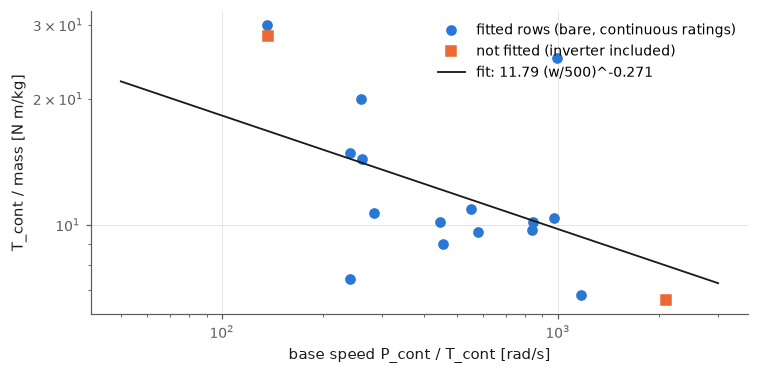

In [32]:
from aircraft_closure.powertrain.machine_database import fit_torque_density, load_machine_database
from aircraft_closure.powertrain.components.motor import DatabaseMassModel

records = load_machine_database()
fit = fit_torque_density(records)
print(f"{len(records)} rows, {sum(r.fit for r in records)} fitted: tau_ref {fit.torque_density_ref_Nm_kg:.3f} N m/kg "
      f"at {fit.speed_ref_rad_s:.0f} rad/s, exponent {fit.exponent_speed:.4f}, RMS log residual {fit.rms_log_residual:.3f}")
model = DatabaseMassModel()
check("DatabaseMassModel defaults are the rounded fit (11.79, 0.271)",
      abs(model.torque_density_ref_Nm_kg - fit.torque_density_ref_Nm_kg) < 0.01
      and abs(model.exponent_speed - fit.exponent_speed) < 0.001)
check("HaloAssumptions carries a second hand copy of the same numbers",
      (assumptions.torque_density_database_Nm_kg, assumptions.exponent_speed_database) == (11.79, 0.271))
rows = [r for r in records if r.fit]
ratio = dict(fit.residuals)
r0 = rows[0]
mass_model_kg = r0.torque_continuous_Nm / fit.torque_density_Nm_kg(r0.speed_base_rad_s())
print(f"{r0.name}: database {r0.mass_kg} kg, fit {mass_model_kg:.2f} kg, residual {ratio[r0.name]:.3f}")
check("residual = model mass / database mass for a fitted row",
      abs(ratio[r0.name] - mass_model_kg / r0.mass_kg) < 1e-12)
check("baseline machine model is 'units', so the fit is not in the baseline", assumptions.machine_mass_model == "units")

fig, ax = plt.subplots(figsize=(7, 3.5))
w = np.array([r.speed_base_rad_s() for r in rows]); tau = np.array([r.torque_density_continuous_Nm_kg() for r in rows])
ax.loglog(w, tau, "o", color=blue, label="fitted rows (bare, continuous ratings)")
others = [r for r in records if not r.fit and r.torque_continuous_Nm is not None and r.speed_base_rad_s()]
ax.loglog([r.speed_base_rad_s() for r in others], [r.torque_density_continuous_Nm_kg() for r in others], "s",
          color=orange, label="not fitted (inverter included)")
grid = np.geomspace(50, 3000, 50)
ax.loglog(grid, fit.torque_density_Nm_kg(grid), color=ink, lw=1.2,
          label=f"fit: {fit.torque_density_ref_Nm_kg:.2f} (w/500)^-{fit.exponent_speed:.3f}")
ax.set_xlabel("base speed P_cont / T_cont [rad/s]"); ax.set_ylabel("T_cont / mass [N m/kg]")
ax.legend(); plt.tight_layout(); plt.show()

The fit says mass at fixed **power** falls as ω^(a−1) = ω^−0.73: a faster machine is lighter, which is why plan 033
paired it with an explicit gear-stage model (a faster motor needs more reduction).

---
## 6. `vehicle/powertrain_installation.py`

In [33]:
show_source("src/aircraft_closure/vehicle/powertrain_installation.py")

# src/aircraft_closure/vehicle/powertrain_installation.py  lines 1-70
   1  """Installed powertrain: topology instances placed on the airframe.
   2  
   3  Mass of each instance is `count * component.get_mass()`; the installation
   4  factor covers mounts, cabling and cooling that the component models omit.
   5  Symmetric multiplicity places all copies of an instance at one x/z position,
   6  which is exact for CG when copies are mirrored about the symmetry plane.
   7  
   8  Tier 19: an optional `InstalledCooling` (a heat exchanger rejecting every
   9  heat load except the sources named in `sources_excluded`) adds its mass as the
  10  item "heat_exchanger". It is not a topology instance: it has no power ports;
  11  its fan power is a bus load that flight points add.
  12  """
  13  from dataclasses import dataclass
  14  from typing import Any
  15  
  16  import aerosandbox as asb
  17  
  18  
  19  @dataclass(frozen=True)
  20  class InstalledInstance:
  21      instance_na

- **L1-11 docstring:** installed mass = `count × component.get_mass()` × installation factor. All copies of an
  instance sit at one (x, z): exact for the CG when copies are mirrored about the symmetry plane (they have no y).
  Tier 19 (decision `028`): the optional heat exchanger is **not** a topology instance (it has no power ports); its
  fan power is a bus load the flight point adds, and its mass is the item `"heat_exchanger"`.
- **L19-23 `InstalledInstance`:** an instance name and its station. `x_m` and `z_m` may be symbolic (the Halo
  stations depend on the wing position, a design variable).
- **L26-29 `InstalledMass`:** a name and an `asb.MassProperties`.
- **L32-37 `InstalledCooling`:** the exchanger, its station, and `sources_excluded` (heat loads cooled elsewhere, for
  example gearbox oil coolers; validated in `thermal/heat.py`).
- **L40-45 `PowertrainInstallation`:** topology, locations, factor, cooling.
- **L47-55 `__post_init__`:** each instance located exactly once. L49-50 rejects duplicates (the message prints the
  sorted list of all located names, not just the duplicates). L51-55 rejects missing and unknown names. A forgotten
  instance would otherwise drop its mass silently.
- **L57-67 `get_instance_mass_properties`:** per instance, mass = factor × count × `get_mass()` at its station
  (L61-63). The exchanger is appended **without** the installation factor (L64-66).
- **L69-70 `get_mass_properties`:** the sum, starting from a zero-mass `MassProperties` so `sum` works on symbolic
  masses. `asb.MassProperties.__add__` mass-weights the CG. Inertias are zero: point masses only.

In [34]:
installation = aircraft.powertrain
items = {i.instance_name: i.mass_properties for i in installation.get_instance_mass_properties()}
for name, mp in items.items():
    count = topology.instances[name].count if name in topology.instances else 1
    print(f"  {name:<20} count {count}  mass {float(mp.mass):8.1f} kg  x {float(mp.x_cg):6.3f} m  z {float(mp.z_cg):6.3f} m")
total = installation.get_mass_properties()
print(f"powertrain total {float(total.mass):.1f} kg at x_cg {float(total.x_cg):.3f} m; factor {installation.installation_factor}")

check("instance masses reproduce the baseline powertrain breakdown",
      all(abs(float(items[n].mass) - kg) < 1e-6 for n, kg in ref.powertrain_masses_kg))
check("powertrain total = the baseline 'powertrain' component mass",
      abs(float(total.mass) - dict(ref.component_masses_kg)["powertrain"]) < 1e-6)
check("motor item = 4 lane motors x one lane's mass",
      abs(float(items["motor"].mass) - 4 * motor.get_mass()) < 1e-9)
check("CG is the mass-weighted mean of the item stations",
      abs(float(total.x_cg) - sum(float(m.mass * m.x_cg) for m in items.values()) / float(total.mass)) < 1e-9)

from aircraft_closure.vehicle.powertrain_installation import InstalledInstance, PowertrainInstallation
locations = installation.locations
for label, bad in (("one missing", locations[:-1]), ("one twice", locations + locations[:1]),
                   ("unknown", locations + (InstalledInstance("ghost", 0.0),))):
    try:
        PowertrainInstallation(topology, bad)
    except ValueError as error:
        print(f"  rejected {label:<12} {str(error)[:110]}")
doubled = replace(installation, installation_factor=2.0)
hx_kg = float(doubled.cooling.heat_exchanger.get_mass())
check("FINDING: the installation factor scales every instance but not the heat exchanger",
      abs(float(doubled.get_mass_properties().mass) - (2 * (float(total.mass) - hx_kg) + hx_kg)) < 1e-6)

  turboshaft           count 2  mass    421.7 kg  x  6.294 m  z  0.650 m
  generator            count 2  mass    281.7 kg  x  6.294 m  z  0.650 m
  battery              count 1  mass    475.1 kg  x  4.311 m  z -0.200 m
  motor                count 4  mass    425.6 kg  x  5.111 m  z  2.200 m
  gearbox              count 2  mass    292.4 kg  x  5.111 m  z  2.200 m
  propulsor            count 2  mass    674.9 kg  x  5.111 m  z  2.700 m
  generator_gearbox    count 2  mass    144.2 kg  x  6.294 m  z  0.650 m
  protection_string    count 2  mass      4.5 kg  x  4.311 m  z -0.200 m
  protection_bus_tie   count 1  mass      9.1 kg  x  4.311 m  z -0.200 m
  cable_bus_tie        count 1  mass     14.9 kg  x  4.311 m  z -0.200 m
  heat_exchanger       count 1  mass    126.9 kg  x  5.111 m  z  0.000 m
powertrain total 2870.9 kg at x_cg 5.320 m; factor 1.0
PASS  instance masses reproduce the baseline powertrain breakdown
PASS  powertrain total = the baseline 'powertrain' component mass
PASS  moto

---
## Gotchas

- **Ports live outside the components.** A component class knows nothing about networks; `port_specs_for` attaches
  ports by type. The generator's inverter is the one case where the type is not enough (`rectifier_port_specs`).
- **`motor` is a lane motor with Tier 18.** Every motor figure (rating, torque, mass, operating margin) is per lane;
  totals are count × that. `redundancy_counts` recovers the lane count as motor count // propulsor count.
- **Operating margins are per copy, design margins are totals.** Operating margins never multiply by a count; design
  margins multiply on combiners and buses (and never for speed).
- **Thermal machines lose their power margin.** With `thermal_model` set, `operating_margins` writes no
  `power_shaft_W` margin for motors and generators; temperature is limited by the caller instead.
- **Design margins are not in the Halo problem.** Only operating margins are constrained (through `flight_point`).
  The Halo tuple named `design_margins` is unrelated.
- **`battery_with_strings(pack, 1)` returns the same object.** Identity checks (`is`) work; mutation would be shared
  (the dataclasses are frozen, so it cannot happen).
- **Failure states are symmetric.** A lane out or bus out applies to every rotor at once.

## Limits / what it can't do

- No speed or torque envelope propagation through gearboxes (deferred in `003`); a gearbox has only a power bound.
- Bus power design margins are loss-free and use shaft ratings for machines (optimistic, `003`).
- No asymmetric (one-rotor) failure, no roll trim, no double failures in the baseline (`NEXT_STEPS.md` §6).
- `redundancy_counts` and `degraded_state` only work on `build_series_hybrid` networks (hard-coded instance names);
  the XV-15 topology has no `motor` and would raise `KeyError`.
- Installation is point masses at one (x, z) per instance: no y, no inertia.
- The torque-density fit is two parameters on 15 machines with a 1.45 scatter factor; it is not used by the baseline.

## What's next (from `docs/NEXT_STEPS.md`)

- §5: electrical layer on by default (it brings the feeder design margins discussed above into play).
- §6: asymmetric and double failures, and the interconnect-shaft versus electrical cross-strapping trade.

## Findings

1. **`compatibility.design_margins` is not used by the Halo sizing** (`examples/halo_sizing.py:1269` is a local tuple
   with the same name; only tests import the function). The Tier 3 adjacent-rating checks are not enforced or
   reported for the baseline.
2. **On the sized Halo one design margin is negative:** `motor.shaft->gearbox.shaft_in max_power_W` = −0.394
   (2 lanes × 527.8 kW into a 757.5 kW gearbox). The lane motors are torque-sized from whole units; the gearbox
   rating is a separate design variable (`halo_sizing.py:690-694`). Operating margins keep each point feasible, but the
   rating chain is inconsistent. Enforcing it would raise the gearbox rating to 1,055.6 kW (+39 %).
3. **Bus voltage-window design margins vanish with battery strings** (`compatibility.py:232-234`): the only port on
   the bus is `protection_string.output` (`sets_voltage=False`), so no voltage check is written. Same with the Tier 15
   layer without DC/DC.
4. **Passive feeder envelopes** (`compatibility.py:90-91`): "power" = I_max × V_max. The direct-connection check
   (`:214-218`) then reports a cable feeding an inverter as −1.10 on the Halo with the layer on, and the bus supply
   counts string contactors' I_max × V_max instead of the pack rating.
5. **`degraded_state` accepts a negative `count_buses_failed`** (`redundancy.py:59, 64`): −1 passes the tie check and
   gives 3 active lanes of 2 installed. Not reachable from `failure_hover_cases`.
6. **The installation factor is not applied to the heat exchanger** (`powertrain_installation.py:64-66`), although
   the docstring says the factor covers installation. No effect on the Halo (factor 1.0).
7. **The machine-database fit is copied by hand** into `motor.py:114-116` and `halo_sizing.py:395-397`; only the
   first copy is test-guarded. `MachineRecord.speed_base_rad_s` docstring says "else None" but returns
   `speed_rated_rad_s` (which may be None).

## Review questions

<details><summary>Why are port declarations in a separate module and not in the component classes?</summary>

So the physics classes stay plain (evaluate, limits, mass) and reusable outside a network, and so one class can play
two roles: the `Inverter` is a motor drive (dc IN, ac OUT) or an active rectifier (ac IN, dc OUT) depending on the
port specs the builder passes. `port_specs_for` walks the MRO so subclasses inherit ports.
</details>

<details><summary>What is the difference between operating margins and design margins, and which does the Halo constrain?</summary>

Operating margins compare one instance's port values at a flight point with its own limits (per copy, symbolic in
the point's states). Design margins compare adjacent ratings across connections and buses, from component parameters
only (totals over counts on combiners and buses). The Halo constrains operating margins at every point through
`flight_point`; it never calls `design_margins`.
</details>

<details><summary>The sized Halo has motor.shaft->gearbox.shaft_in at −0.39. Is the design infeasible?</summary>

No. Every flight point satisfies the gearbox's operating power margin (it binds in hover). The negative design margin
says the two lane motors could deliver 1,055.6 kW continuous into a 757.5 kW gearbox. The motors are sized by torque
(bus-out lane torque at T_max) from whole units; the gearbox by hover power. In hardware a controller power or torque
limit would protect the gearbox; in the model, enforcing the margin would cost a 39 % larger gearbox rating.
</details>

<details><summary>How does a bus failure change the active lanes, and what does it not change?</summary>

Active lanes per rotor = requested lanes − failed buses × (lanes / buses). For the Halo (2 lanes, 2 buses) a bus out
leaves 1 lane per rotor, carrying the whole gearbox torque. Strings and generators stay active: the failed bus's
sources feed the other bus through the tie, whose current and loss the flight point adds. It is applied to both
rotors.
</details>

<details><summary>What does battery_with_strings do to an ECM pack and why is the SOC unchanged?</summary>

It scales `count_parallel` by the active fraction, so capacity, current ratings, mass (thermal capacitance) and
conductance scale by f and the resistance by 1/f; the voltage window is unchanged. The strings are in parallel at one
voltage, so they share one SOC; isolating one removes its capacity and current share, not its state of charge.
</details>

<details><summary>Why does the battery voltage range take the high root and what does NaN mean?</summary>

V = OCV − I R with V I = P gives V² − OCV V + R P = 0. The high root is the low-current (physical) branch. Above
P = OCV² / (4R) the discriminant is negative: no current can deliver that power, and `np.sqrt` returns NaN, flagging an
infeasible rating while keeping the function a pure traceable expression.
</details>

In [35]:
check_summary()

49 of 49 checks passed
